## Offline RAG Evaluation

In [44]:
import json
from tqdm.auto import tqdm

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from minsearch import VectorSearch
from sentence_transformers import SentenceTransformer
from openai import OpenAI

In [2]:
with open("documents-with-ids.json", "rt") as f_in:
    documents = json.load(f_in)

In [3]:
df_ground_truth = pd.read_csv("ground-truth-data.csv")
ground_truth = df_ground_truth.to_dict(orient="records")

In [4]:
doc_idx = {d["id"]: d for d in tqdm(documents)}

  0%|          | 0/948 [00:00<?, ?it/s]

### Index data

In [5]:
model_name = "multi-qa-MiniLM-L6-cos-v1"
model = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
vectors = []

for doc in tqdm(documents):
    vector = model.encode(doc["question"] + " " + doc["text"])
    vectors.append(vector)

  0%|          | 0/948 [00:00<?, ?it/s]

In [8]:
vectors = np.array(vectors)

In [9]:
vindex = VectorSearch(keyword_fields=["course"])
vindex.fit(vectors, documents)

### Retrieval

In [13]:
def search(query, course="data-engineering-zoomcamp"):
    encoded_query = model.encode(query)

    results = vindex.search(
        encoded_query,
        filter_dict={"course": course},
        num_results=5,
        output_ids=True
    )
    return results

In [14]:
search("how to submit homework?")

[{'text': 'No, late submissions are not allowed. But if the form is still not closed and it’s after the due date, you can still submit the homework. confirm your submission by the date-timestamp on the Course page.y\nOlder news:[source1] [source2]',
  'section': 'General course-related questions',
  'question': 'Homework - Are late submissions of homework allowed?',
  'course': 'data-engineering-zoomcamp',
  'id': 'be5bfee4',
  '_id': 15},
 {'text': 'You can find the latest and up-to-date deadlines here: https://docs.google.com/spreadsheets/d/e/2PACX-1vQACMLuutV5rvXg5qICuJGL-yZqIV0FBD84CxPdC5eZHf8TfzB-CJT_3Mo7U7oGVTXmSihPgQxuuoku/pubhtml\nAlso, take note of Announcements from @Au-Tomator for any extensions or other news. Or, the form may also show the updated deadline, if Instructor(s) has updated it.',
  'section': 'General course-related questions',
  'question': 'Homework - What are homework and project deadlines?',
  'course': 'data-engineering-zoomcamp',
  'id': 'a1daf537',
  '_id

### RAG Pipeline

In [16]:
def build_prompt(query, search_results):
    prompt_template = """
You are the teaching assistant. Answer the QUESTION based on the CONTEXT given between ```.
Use only the facts from the CONTEXT to answer the QUESTION.

QUESTION: {question}
CONTEXT: ```{context}```
""".strip()

    context = ""
    for doc in search_results:
        context += f"section: {doc['section']}\nquestion: {doc['question']}\nanswer: {doc['text']}\n\n"

    prompt = prompt_template.format(question=query, context=context)
    return prompt

In [18]:
client = OpenAI()

def llm(prompt, model="gpt-4o-mini"):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

In [19]:
def rag(query, course="data-engineering-zoomcamp", model="gpt-4o-mini"):
    search_results = search(query, course)
    prompt = build_prompt(query, search_results)
    answer = llm(prompt, model=model)
    return answer

In [20]:
ground_truth[7]

{'question': 'Where are the course prerequisites listed?',
 'course': 'data-engineering-zoomcamp',
 'document': '1f6520ca'}

In [21]:
rag(ground_truth[7]["question"])

'The course prerequisites are listed on GitHub at the link: DataTalksClub data-engineering-zoomcamp#prerequisites.'

In [11]:
doc_idx[ground_truth[7]["document"]]["text"]

'GitHub - DataTalksClub data-engineering-zoomcamp#prerequisites'

### Cosine Similarity

In [31]:
def process_record(record):
    answer_llm = rag(record["question"], record["course"])

    doc_id = record["document"]
    doc_orig = doc_idx[doc_id]
    answer_orig = doc_orig["text"]

    return {
        "answer_llm": answer_llm,
        "answer_orig": answer_orig,
        "document": doc_id,
        "question": record["question"],
        "course": record["course"]
    }

In [32]:
def compute_similarity(record):
    encoded_ans_llm = model.encode(record["answer_llm"])
    encoded_ans_orig = model.encode(record["answer_orig"])
    return encoded_ans_llm.dot(encoded_ans_orig)

In [33]:
record = process_record(ground_truth[15])
score = compute_similarity(record)

In [34]:
record

{'answer_llm': "You will not receive a confirmation email after registering for the Data Engineering Bootcamp, as you're already accepted. You can start learning and submitting homework without needing to be on a registered list. Registration is simply to gauge interest before the course start date.",
 'answer_orig': "You don't need it. You're accepted. You can also just start learning and submitting homework without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.",
 'document': '0bbf41ec',
 'question': 'When will I receive the confirmation email after registering for the Data Engineering Bootcamp?',
 'course': 'data-engineering-zoomcamp'}

In [35]:
score

np.float32(0.6184097)

In [37]:
scores = []

for rec in tqdm(ground_truth[:10]):
    record = process_record(rec)
    score = compute_similarity(record)
    scores.append(score)

  0%|          | 0/10 [00:00<?, ?it/s]

In [41]:
df_scores = pd.DataFrame(scores, columns=["Scores"])

Text(0.5, 0, 'Cosine Similarity')

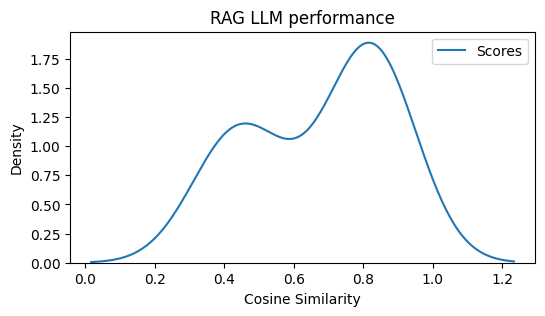

In [58]:
plt.figure(figsize=(6, 3))
sns.kdeplot(df_scores)

plt.title("RAG LLM performance")
plt.xlabel("Cosine Similarity")

In [77]:
records = []

for rec in tqdm(ground_truth[:10]):
    records.append(process_record(rec))

  0%|          | 0/10 [00:00<?, ?it/s]

In [78]:
df_sample = pd.DataFrame(records)
df_sample["cosine_similarity"] = scores
df_sample

,answer_llm,answer_orig,document,question,course,cosine_similarity
0,The course will begin on 15th January 2024 at ...,The purpose of this document is to capture fre...,c02e79ef,When does the course begin?,data-engineering-zoomcamp,0.545873
1,"To get the course schedule, you can subscribe ...",The purpose of this document is to capture fre...,c02e79ef,How can I get the course schedule?,data-engineering-zoomcamp,0.800182
2,The link for course registration is not explic...,The purpose of this document is to capture fre...,c02e79ef,What is the link for course registration?,data-engineering-zoomcamp,0.388815
3,You can receive course announcements by joinin...,The purpose of this document is to capture fre...,c02e79ef,How can I receive course announcements?,data-engineering-zoomcamp,0.771628
4,"To join the Slack channel, you need to registe...",The purpose of this document is to capture fre...,c02e79ef,Where do I join the Slack channel?,data-engineering-zoomcamp,0.434029
5,You can find the prerequisites for this course...,GitHub - DataTalksClub data-engineering-zoomca...,1f6520ca,Where can I find the prerequisites for this co...,data-engineering-zoomcamp,0.861533
6,"To check the prerequisites for this course, vi...",GitHub - DataTalksClub data-engineering-zoomca...,1f6520ca,How do I check the prerequisites for this course?,data-engineering-zoomcamp,0.853420
7,The course prerequisites are listed on GitHub ...,GitHub - DataTalksClub data-engineering-zoomca...,1f6520ca,Where are the course prerequisites listed?,data-engineering-zoomcamp,0.790898
8,The requirements for joining the course are to...,GitHub - DataTalksClub data-engineering-zoomca...,1f6520ca,What are the requirements for joining this cou...,data-engineering-zoomcamp,0.441856
9,The list of prerequisites for the course can b...,GitHub - DataTalksClub data-engineering-zoomca...,1f6520ca,Where is the list of prerequisites for the cou...,data-engineering-zoomcamp,0.853512


### LLM as a Judge

In [82]:
prompt_template = """
You are the expert for evaluating Retrival-Augmented Generation (RAG).
Your task is to analyze the relevance of the generated answer compared to the original answer.
Based on the relevance and similarity of the answers, you need to classify each document as:
- "NON_RELEVANT"
- "PARTIALY_RELEVANT"
- "RELEVANT"

Below is the data for your evaluation:
ORIGINAL_ANSWER: ```{answer_orig}```
GENERATED_QUESTION: ```{question}```
GENERATED_ANSWER: ```{answer_llm}```

Use the parsable JSON format below for the output.
{{
    "relevance": "NON_RELEVANT" | "PARTIALY_RELEVANT" | "RELEVANT",
    "explanation": "[Provide brief explanation in less than 30 words]"
}}
""".strip()

In [79]:
samples = df_sample.to_dict(orient="records")

In [83]:
prompt = prompt_template.format(**samples[0])
print(prompt)

You are the expert for evaluating Retrival-Augmented Generation (RAG).
Your task is to analyze the relevance of the generated answer compared to the original answer.
Based on the relevance and similarity of the answers, you need to classify each document as:
- "NON_RELEVANT"
- "PARTIALY_RELEVANT"
- "RELEVANT"

Below is the data for your evaluation:
ORIGINAL_ANSWER: ```The purpose of this document is to capture frequently asked technical questions
The exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1
Subscribe to course public Google Calendar (it works from Desktop only).
Register before the course starts using this link.
Join the course Telegram channel with announcements.
Don’t forget to register in DataTalks.Club's Slack and join the channel.```
GENERATED_QUESTION: ```When does the course begin?```
GENERATED_ANSWER: ```The course will begin on 15th January 2024 at 17h00.```

Use the parsable JSON format below

In [85]:
evals = []

for sample in tqdm(samples):
    prompt = prompt_template.format(**sample)
    evaluation = json.loads(llm(prompt))
    evals.append(evaluation)

  0%|          | 0/10 [00:00<?, ?it/s]

In [87]:
df_evals = pd.DataFrame(evals)
df_evals

,relevance,explanation
0,RELEVANT,The generated answer accurately provides the e...
1,RELEVANT,The generated answer directly addresses how to...
2,PARTIALY_RELEVANT,The generated answer acknowledges the registra...
3,RELEVANT,The generated answer accurately captures the m...
4,RELEVANT,The generated answer directly addresses the qu...
5,RELEVANT,The generated answer directly addresses the qu...
6,RELEVANT,The generated answer directly addresses the qu...
7,RELEVANT,The generated answer accurately reflects the i...
8,PARTIALY_RELEVANT,The generated answer provides details about jo...
9,RELEVANT,The generated answer directly references the o...


In [88]:
df_evals.relevance.value_counts()

relevance
RELEVANT             8
PARTIALY_RELEVANT    2
Name: count, dtype: int64

In [94]:
filtered_non_relevants = [e for e in evals if e["relevance"] == "PARTIALY_RELEVANT"]
filtered_non_relevants

[{'relevance': 'PARTIALY_RELEVANT',
  'explanation': 'The generated answer acknowledges the registration link is mentioned but does not provide it, only directing to the source document.'},
 {'relevance': 'PARTIALY_RELEVANT',
  'explanation': 'The generated answer provides details about joining the course but does not directly reference GitHub or the specific prerequisites mentioned in the original answer.'}]

In [99]:
samples[2], samples[8]

({'answer_llm': 'The link for course registration is not explicitly provided in the context. However, it states, "Register before the course starts using this link." You would need to refer to the source document to find the actual link.',
  'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
  'document': 'c02e79ef',
  'question': 'What is the link for course registration?',
  'course': 'data-engineering-zoomcamp',
  'cosine_similarity': 0.3888145983219147},
 {'answer_llm': "The requirements for joining the course are to register before the course starts, join t